# Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tracks2026.csv")
df_original = df # Safety measure for manipulation of data

In [3]:

print(df['explicit'].dtype)
print(df['explicit'].unique())

bool
[False  True]


In [ ]:
# Attempting to remove NA values from the dataset, there seems to be a pattern of if there are N/A values for a variable there are exactly 40 N/A's in the row 
# I am going to try to find if the N/A's are all in the same 40 rows, I believe I can just remove those rows if that is the case


# Count N/A values per row
na_per_row = df.isnull().sum(axis=1)

# Find rows with at least one N/A
rows_with_na = na_per_row[na_per_row > 0]

print("Statistics for rows with N/A values:")
print(f"Number of rows with at least 1 N/A: {len(rows_with_na)}")
print(f"Average N/A's per affected row: {rows_with_na.mean():.2f}")
print(f"\nDistribution of N/A counts in affected rows:")
print(rows_with_na.value_counts().sort_index())
print(f"\nHypothesis check - Do all N/A's cluster in same rows?")
print(f"Max N/A's in a single row: {rows_with_na.max()}")
print(f"Total unique rows with N/A: {len(rows_with_na)}")
print(f"Total N/A values in dataset: {df.isnull().sum().sum()}")

Statistics for rows with N/A values:
Number of rows with at least 1 N/A: 40
Average N/A's per affected row: 4.97

Distribution of N/A counts in affected rows:
4     1
5    39
Name: count, dtype: int64

Hypothesis check - Do all N/A's cluster in same rows?
Max N/A's in a single row: 5
Total unique rows with N/A: 40
Total N/A values in dataset: 199


All of the data rows with non applicaples seem to fall within the same 40 rows.

Seeing this issue I believe we could remove those 40 data rows and still have a strong model.

I will remove those 40 data rows now.

In [5]:
# Remove all rows with NA values
df = df.dropna()
df = df.drop(['track_id'], axis=1)

print(f"Dataset shape after removing NA values: {df.shape}")
print(f"Original data set with no NA values removed: {df_original.shape}")
print(f"Rows removed: {len(df_original) - len(df)}")
print(f"\nVerification - Missing values remaining: {df.isnull().sum().sum()}")

Dataset shape after removing NA values: (1960, 16)
Original data set with no NA values removed: (2000, 17)
Rows removed: 40

Verification - Missing values remaining: 0


Reviewing the document for Exploritory Data Analysis recommends Log Transformation and Standard Scaler for acousticness and valence, and Log Transfer for Robust Scaler for all other columns, I will set up and apply those to the data

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Define column groups
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'popularity', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p)), # Apply log transformation with added 1 to reduce skewness and prevent error from log(0)
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([ # Apply log transformation with added 1 to reduce skewness and prevent error from log(0)
     ('log', FunctionTransformer(func=np.log1p)),
     ('scaler', RobustScaler())
])

# Debugging output to verify column groupings
print("Passthrough columns:")
print(passthrough_cols)
print("\nNo outlier cols:")
print(no_outlier_cols)
print("\nOutlier cols negative:")
print(outlier_cols_neg)
print("\nOutlier cols positive:")
print(outlier_cols_pos)

# Combined preprocessor with explicit remainder handling
preprocessor = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
    ],
    remainder='passthrough'
)

Passthrough columns:
['explicit', 'key', 'mode', 'time_signature', 'track_genre']

No outlier cols:
['valence', 'popularity', 'acousticness']

Outlier cols negative:
['loudness']

Outlier cols positive:
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']


Succesfully able to seperate each column into their respective attributes to accurately apply the log transformations and scalers.

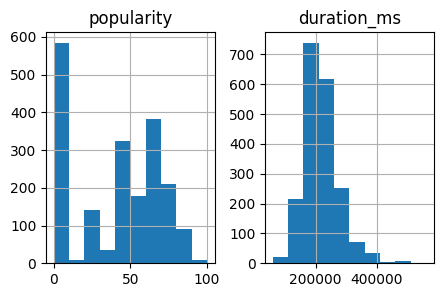

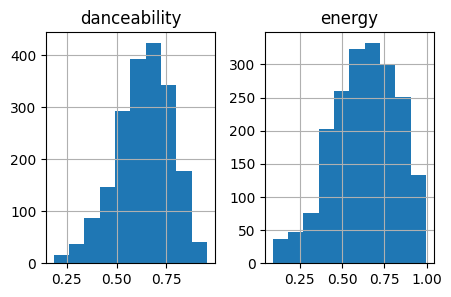

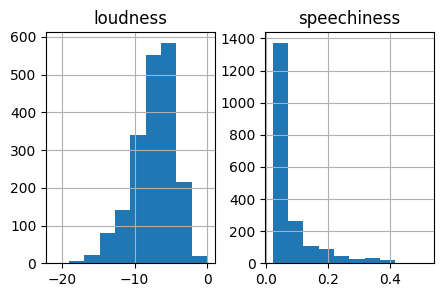

In [7]:
df[['popularity','duration_ms']].hist(figsize=(5,3)) # Testing catagorical numerical variables, 
df[['danceability', 'energy']].hist(figsize=(5,3))
df[['loudness', 'speechiness']].hist(figsize=(5,3))
plt.show()

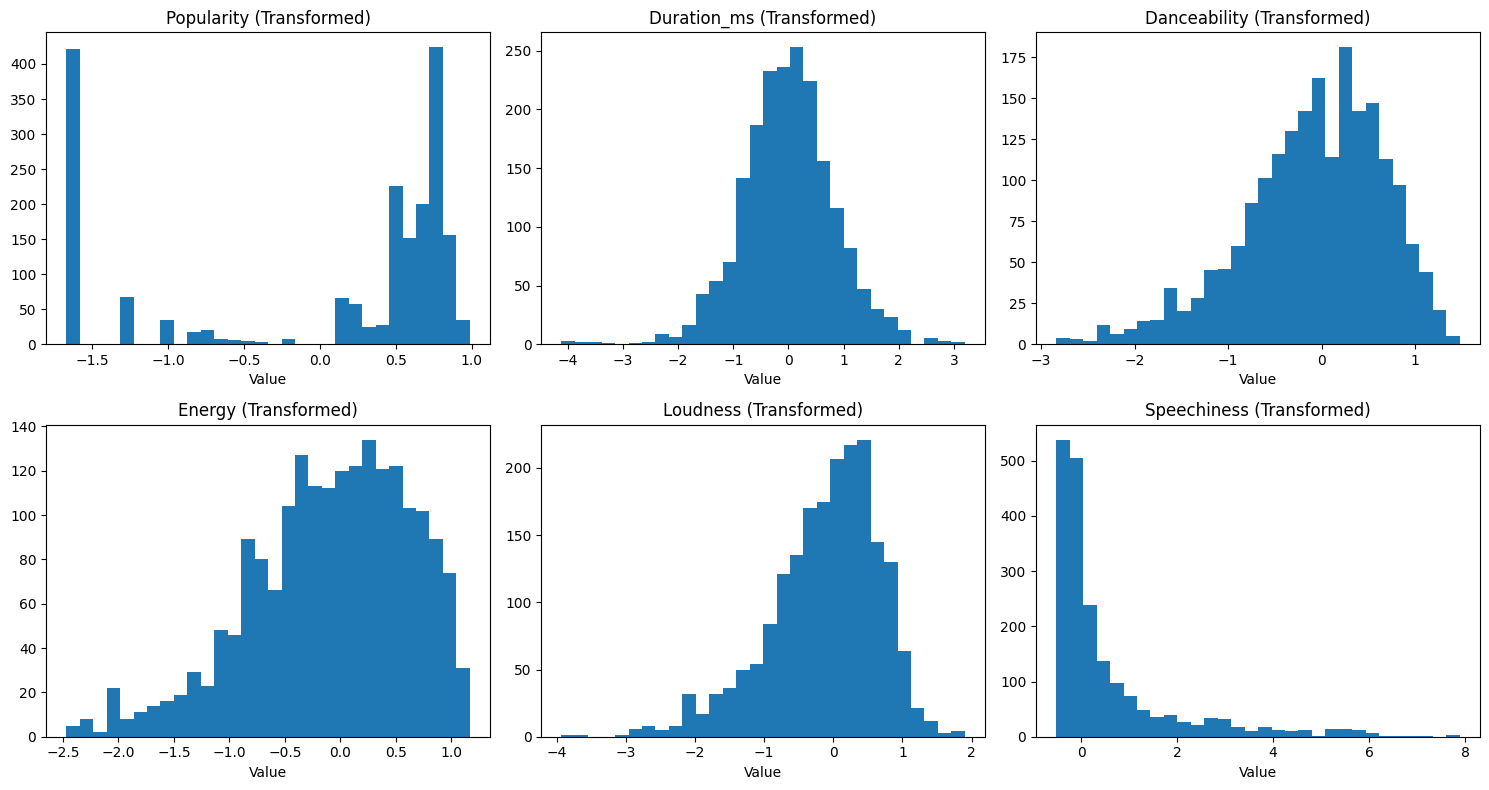


Transformed data statistics:
         popularity  duration_ms  danceability      energy     loudness  \
count   1960.000000   1960.00000   1960.000000  1960.00000  1960.000000   
unique    89.000000   1629.00000    541.000000   668.00000  1542.000000   
top       -1.669934     -0.85068      0.005246     0.08731     0.350897   
freq     422.000000     15.00000     19.000000    19.00000    15.000000   

        speechiness  
count    1960.00000  
unique    695.00000  
top         0.11605  
freq       17.00000  


In [ ]:
# Apply preprocessing and create transformed dataframe
transformed_array = preprocessor.fit_transform(df)

# Manually reconstruct column order due to issues with ColumnTransformer's handling of passthrough columns
output_cols = (no_outlier_cols + outlier_cols_neg + outlier_cols_pos + passthrough_cols)

df_transformed = pd.DataFrame(
    transformed_array,
    columns=output_cols
)
# Plot the TRANSFORMED data
fig, axes = plt.subplots(2, 3, figsize=(15, 8))


# Popularity and duration_ms (after log + StandardScaler)
axes[0, 0].hist(df_transformed['popularity'], bins=30)
axes[0, 0].set_title('Popularity (Transformed)')
axes[0, 0].set_xlabel('Value')

axes[0, 1].hist(df_transformed['duration_ms'], bins=30)
axes[0, 1].set_title('Duration_ms (Transformed)')
axes[0, 1].set_xlabel('Value')

# Danceability and energy (after log + RobustScaler)
axes[0, 2].hist(df_transformed['danceability'], bins=30)
axes[0, 2].set_title('Danceability (Transformed)')
axes[0, 2].set_xlabel('Value')

axes[1, 0].hist(df_transformed['energy'], bins=30)
axes[1, 0].set_title('Energy (Transformed)')
axes[1, 0].set_xlabel('Value')

# Loudness (RobustScaler only) and speechiness (log + RobustScaler)
axes[1, 1].hist(df_transformed['loudness'], bins=30)
axes[1, 1].set_title('Loudness (Transformed)')
axes[1, 1].set_xlabel('Value')

axes[1, 2].hist(df_transformed['speechiness'], bins=30)
axes[1, 2].set_title('Speechiness (Transformed)')
axes[1, 2].set_xlabel('Value')

plt.tight_layout()
plt.show()

print("\nTransformed data statistics:")
print(df_transformed[['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness']].describe())

How did the transformation change the data? To show the difference, we compare both histograms before- and after the transformation.

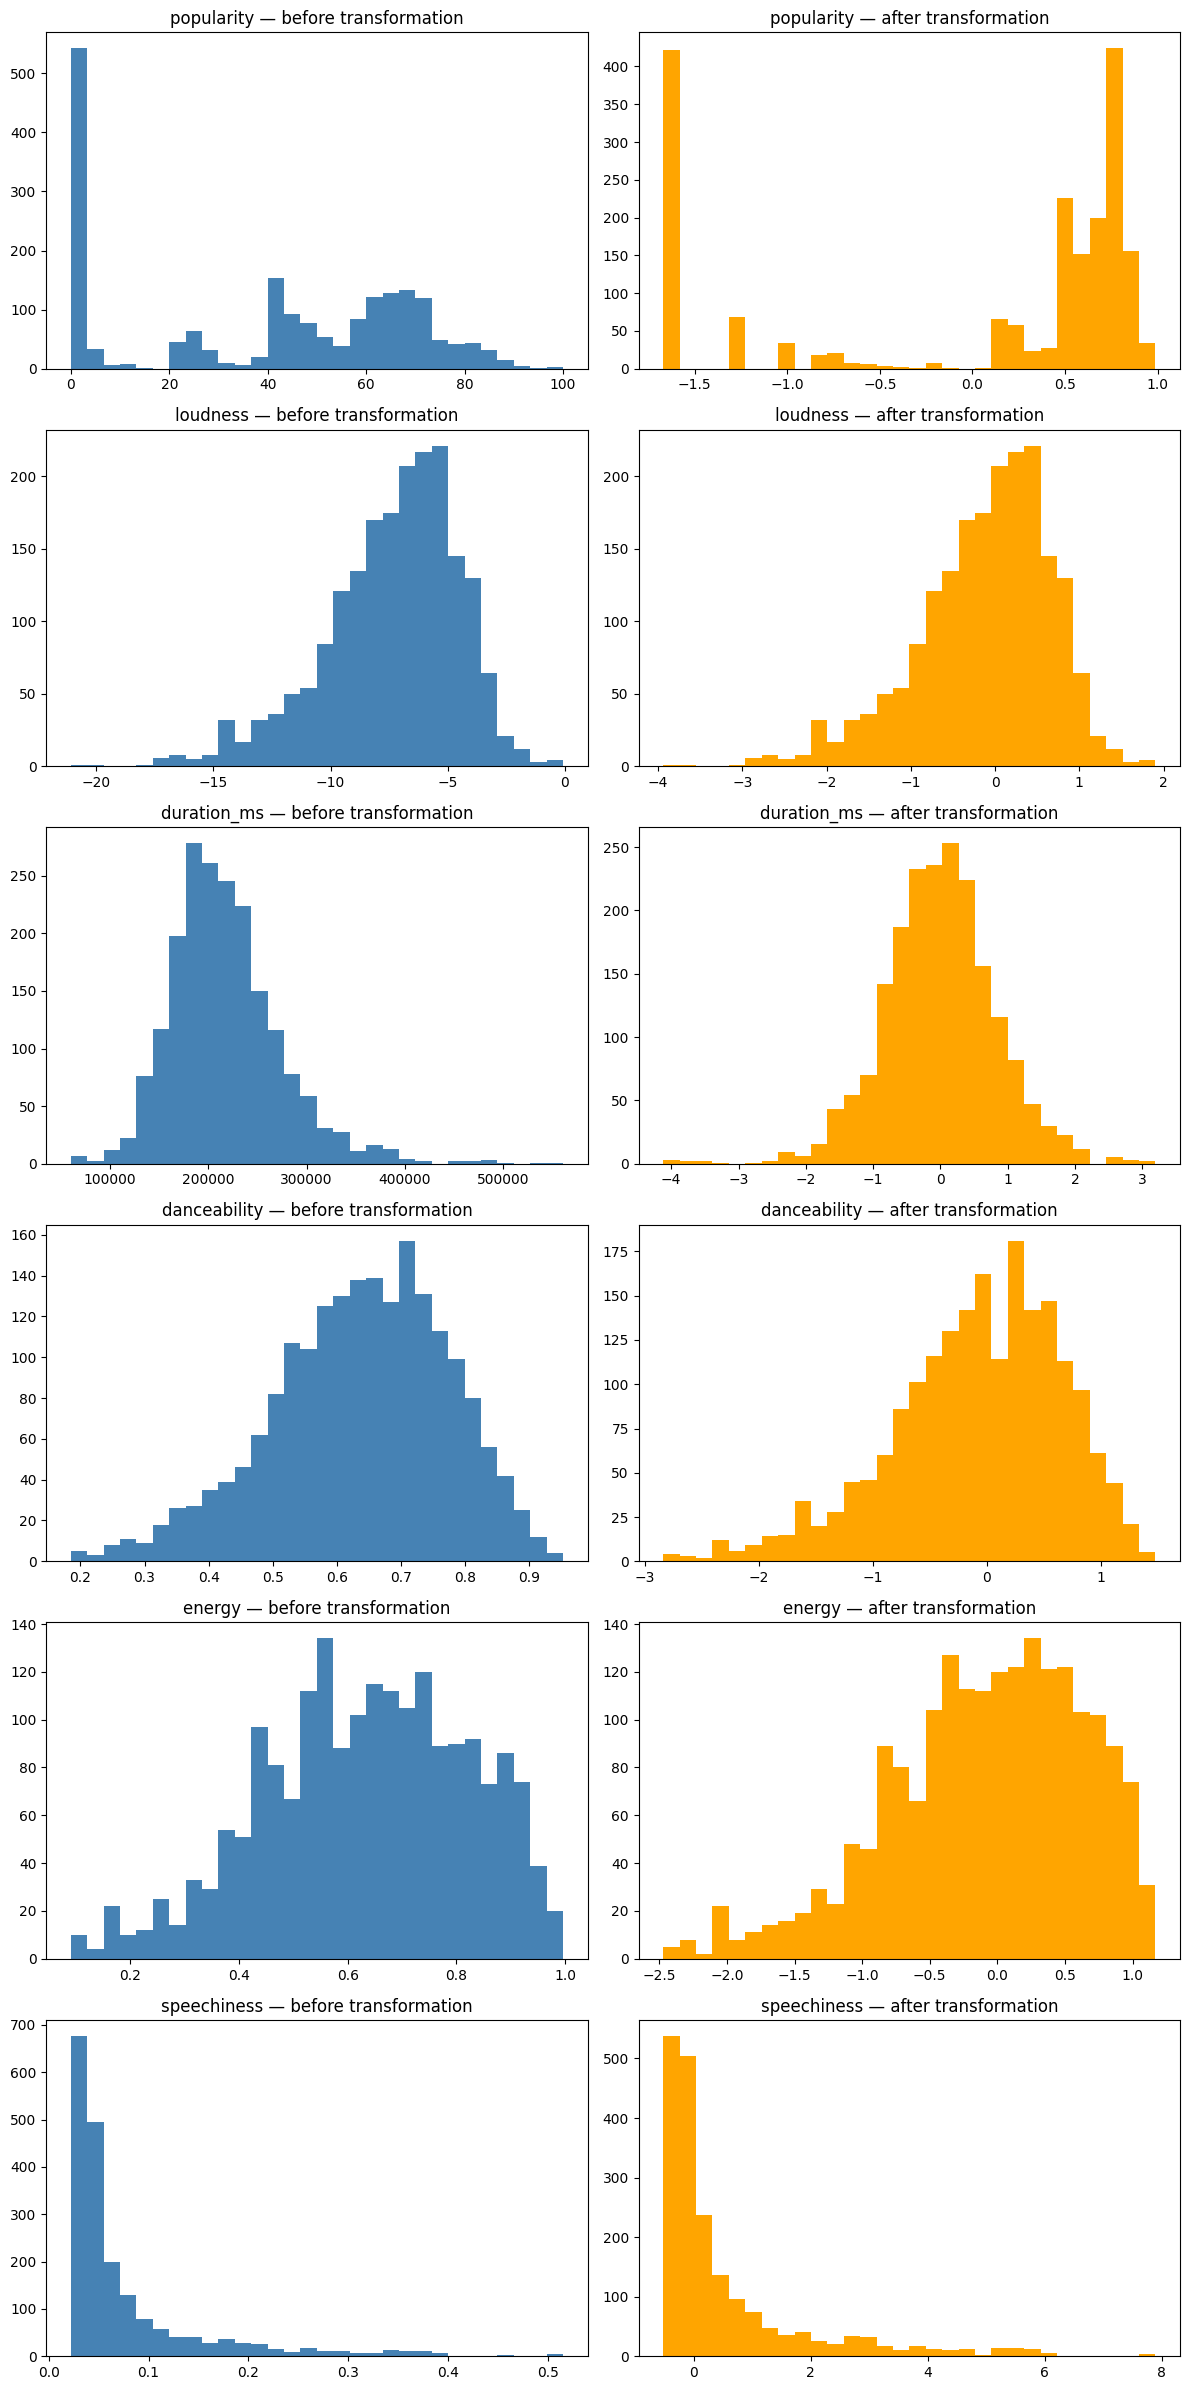

In [9]:
cols_to_compare = ['popularity', 'loudness', 'duration_ms', 'danceability', 'energy', 'speechiness']

fig, axes = plt.subplots(len(cols_to_compare), 2, figsize=(12, 4 * len(cols_to_compare)))

for i, col in enumerate(cols_to_compare):
    axes[i, 0].hist(df[col].dropna(), bins=30, color='steelblue')
    axes[i, 0].set_title(f'{col} — before transformation')

    axes[i, 1].hist(df_transformed[col].astype(float), bins=30, color='orange')
    axes[i, 1].set_title(f'{col} — after transformation')

plt.tight_layout()
plt.show()

Now that the data has been transformed I am going to one hot encode track_genre and convert explicit from boolean to ones and zeros

In [10]:
# Replacing explicit with ones and zeros
scale_mapper = {
    "False": 0,
    "True": 1,
}

df_transformed['explicit'] = df_transformed['explicit'].replace(scale_mapper)

# One hot encoding track_genre
df_transformed = pd.get_dummies(df_transformed, columns=['track_genre'],
                        drop_first=True)

In [11]:
# Check for missing values
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Also check info
print("\nDataFrame info:")
df_transformed.info()


Total missing values: 0

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 1960 entries, 0 to 1959
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   valence                1960 non-null   object
 1   popularity             1960 non-null   object
 2   acousticness           1960 non-null   object
 3   loudness               1960 non-null   object
 4   duration_ms            1960 non-null   object
 5   danceability           1960 non-null   object
 6   energy                 1960 non-null   object
 7   speechiness            1960 non-null   object
 8   instrumentalness       1960 non-null   object
 9   liveness               1960 non-null   object
 10  tempo                  1960 non-null   object
 11  explicit               1960 non-null   object
 12  key                    1960 non-null   object
 13  mode                   1960 non-null   object
 14  time_signature         1960 non-null   ob

After the ColumnTransformer, all numeric columns are stored as objects — this must be corrected before modeling. Furthermore the features with # 15, 16, 17, 18 are coded as boolean. We transform them into numerical values.

In [12]:
bool_cols = [c for c in df_transformed.columns if df_transformed[c].dtype == bool]
object_cols = [c for c in df_transformed.columns if df_transformed[c].dtype == object]

df_transformed[object_cols] = df_transformed[object_cols].astype(float)
df_transformed[bool_cols] = df_transformed[bool_cols].astype(int)

print(df_transformed.dtypes)

valence                  float64
popularity               float64
acousticness             float64
loudness                 float64
duration_ms              float64
danceability             float64
energy                   float64
speechiness              float64
instrumentalness         float64
liveness                 float64
tempo                    float64
explicit                 float64
key                      float64
mode                     float64
time_signature           float64
track_genre_indie-pop      int64
track_genre_pop            int64
track_genre_r-n-b          int64
track_genre_synth-pop      int64
dtype: object


In [13]:
df_transformed.head()

,valence,popularity,acousticness,loudness,duration_ms,danceability,energy,speechiness,instrumentalness,liveness,tempo,explicit,key,mode,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop
0,0.082296,0.522709,0.448524,0.953983,-0.125232,-0.201751,-0.343045,-0.418492,-0.010363,0.249932,0.528641,0.0,10.0,1.0,3.0,0,0,1,0
1,1.066102,0.882222,-0.659722,0.650076,-0.038716,0.651736,-0.114681,0.138373,0.025675,0.100010,-0.467142,0.0,3.0,0.0,4.0,0,1,0,0
2,1.486579,0.583396,0.003012,-0.589184,0.708688,0.758137,-0.118417,-0.331233,0.006187,1.429284,-0.012694,0.0,2.0,0.0,4.0,0,0,0,1
3,0.770855,-1.669934,-0.915276,0.947310,-0.317469,-0.342557,0.642412,2.783162,-0.010363,1.079250,-0.727684,0.0,9.0,1.0,4.0,1,0,0,0
4,-0.098867,0.482969,-0.039238,0.068956,0.964428,0.304195,0.247682,-0.075669,0.013611,-0.595249,0.246500,0.0,4.0,0.0,4.0,0,0,0,1


Believe we are done with Data_Preparation, will now save this to a new csv file

In [14]:
output_path = "df_transformed.csv"
df_transformed.to_csv(output_path, index=False)
print(f"Saved df_transformed to {output_path}")

Saved df_transformed to df_transformed.csv
